# RAG Evaluation — RiskPulse FOMC Intelligence

**Pipeline under evaluation:**
- **Corpus:** 42 FOMC meeting minutes (2021–2026), scraped from federalreserve.gov 
  via `core/document_loader.py`. See `data/documents/corpus_manifest.json` for 
  full provenance.
- **Embeddings:** `sentence-transformers/all-MiniLM-L6-v2`
- **Vector store:** ChromaDB (persistent, local)
- **Generation:** OpenAI `gpt-4.1-mini` with grounded-answer prompt

**Sections:**
1. Corpus overview — document length distribution and ingestion stats
2. Retrieval quality — distance distributions across in-domain, adjacent, 
   and out-of-domain queries
3. Chunk size sensitivity — does 300 / 500 / 800 character chunks matter on 
   real Fed prose?
4. Model comparison — `gpt-4.1-mini` vs `gpt-4o-mini` on FOMC content
5. Prompt engineering — how grounding constraints prevent hallucination

In [1]:
import sys
sys.path.insert(0, "..")

import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from core.rag_chain import (
    ingest_documents,
    retrieve_chunks,
    build_rag_prompt,
    chunk_text,
    CHROMA_PERSIST_DIR,
    EMBEDDING_MODEL,
    DOCUMENTS_DIR,
    MANIFEST_PATH,
)

import chromadb
from chromadb.utils import embedding_functions
import openai
from dotenv import load_dotenv

load_dotenv()

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Corpus Overview

The corpus was built by `scripts/build_corpus.py`, which scrapes the FOMC 
calendar pages on federalreserve.gov, downloads each meeting's minutes HTML, 
cleans boilerplate via BeautifulSoup, validates against quality gates 
(minimum 5,000 chars, FOMC markers present, low boilerplate ratio), and 
writes both the cleaned text and a JSON manifest with full provenance.

The manifest is the single source of truth — every downstream step in this 
notebook reads from it.

Generated:        2026-04-26T00:07:39Z
Document count:   42
Date range:       2021-01-27 → 2026-03-18
Total characters: 2,235,664
Mean per doc:     53,230


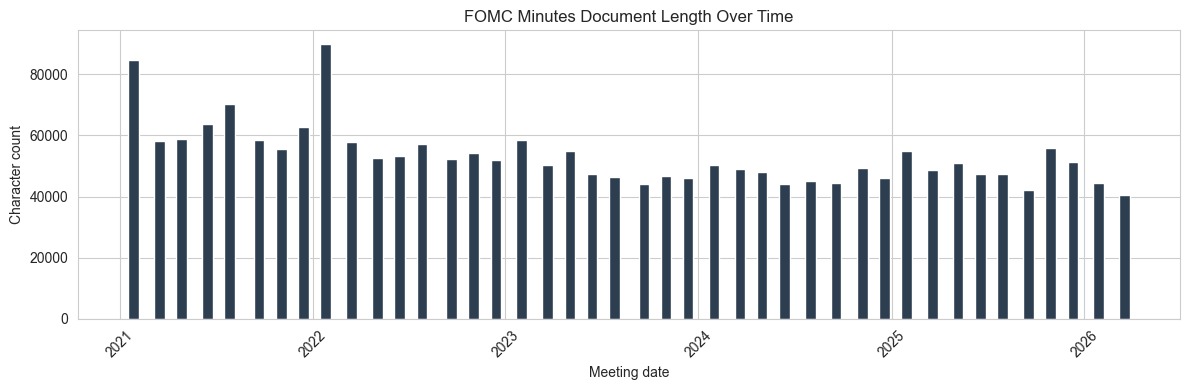

In [2]:
with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

print(f"Generated:        {manifest['generated_at']}")
print(f"Document count:   {manifest['document_count']}")
print(f"Date range:       {manifest['date_range']['earliest']} → {manifest['date_range']['latest']}")
print(f"Total characters: {manifest['total_char_count']:,}")
print(f"Mean per doc:     {manifest['total_char_count'] // manifest['document_count']:,}")

doc_df = pd.DataFrame([
    {"meeting_date": d["meeting_date"], "char_count": d["char_count"]}
    for d in manifest["documents"]
])
doc_df["meeting_date"] = pd.to_datetime(doc_df["meeting_date"])
doc_df = doc_df.sort_values("meeting_date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(doc_df["meeting_date"], doc_df["char_count"], width=20, color="#2c3e50")
ax.set_title("FOMC Minutes Document Length Over Time")
ax.set_ylabel("Character count")
ax.set_xlabel("Meeting date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation 1 — Document length is consistent across the corpus

FOMC minutes consistently run between ~40K and ~90K characters — roughly 
8–18 pages of formal prose per meeting. The 2021 minutes skew slightly 
longer because of expanded language during the pandemic recovery period.

**Why this matters:** consistent document length means chunk counts scale 
predictably with chunk size, and no single document dominates the index. 
This is the kind of corpus-level sanity check that should happen before 
*any* retrieval evaluation — if one doc were 10x larger than the rest, it 
would skew every distance distribution downstream.

In [3]:
n_chunks = ingest_documents()
print(f"Ingested {n_chunks} chunks at default settings (chunk_size=500, overlap=100)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ingested 5598 chunks at default settings (chunk_size=500, overlap=100)


## 2. Retrieval Quality — Distance Distribution

Cosine distance is ChromaDB's measure of how far the query embedding is 
from the chunk embedding. Lower = better. As a heuristic for 
`all-MiniLM-L6-v2` on financial prose:

- **< 0.35** — strong semantic match
- **0.35 – 0.55** — moderate match, usable but watch for drift
- **> 0.55** — weak match, the model may hallucinate from off-topic chunks

The thresholds are wider than the previous evaluation (0.35 / 0.50) because 
real FOMC prose is more lexically diverse than the synthetic corpus that 
preceded it — embeddings spread further apart on natural text.

The test set has three categories:

- **in_domain** — questions the FOMC minutes directly address (rate decisions, 
  inflation, labor, banking, GDP)
- **adjacent** — concepts related to monetary policy but not the FOMC's primary 
  focus (asset prices, QT mechanics, wage dynamics)
- **out_of_domain** — topics the corpus does not cover (crypto, ECB, oil supply)

A well-calibrated retriever should produce visibly separated distance 
distributions across these categories.

In [4]:
test_queries = {
    "in_domain": [
        "What was the Federal Funds Rate decision at the most recent meeting?",
        "How did committee members view inflation outlook in 2024?",
        "What labor market conditions did the FOMC discuss?",
        "What concerns did members raise about banking sector stability?",
        "How did the committee assess GDP growth projections?",
    ],
    "adjacent": [
        "What is the relationship between Fed policy and equity markets?",
        "How does quantitative tightening affect Treasury yields?",
        "Why does the Fed monitor wage growth?",
    ],
    "out_of_domain": [
        "What was Bitcoin's price action in 2024?",
        "How did the European Central Bank respond to inflation?",
        "What is the current oil supply forecast?",
    ],
}

records = []
for category, queries in test_queries.items():
    for q in queries:
        chunks = retrieve_chunks(q, top_k=3)
        for rank, c in enumerate(chunks, start=1):
            records.append({
                "category": category,
                "query": q,
                "rank": rank,
                "distance": c["distance"],
                "source": c["source"],
            })

df_retrieval = pd.DataFrame(records)
df_retrieval.head(10)

,category,query,rank,distance,source
0,in_domain,What was the Federal Funds Rate decision at th...,1,0.2920,2021-12-15_minutes.txt
1,in_domain,What was the Federal Funds Rate decision at th...,2,0.3019,2022-07-27_minutes.txt
2,in_domain,What was the Federal Funds Rate decision at th...,3,0.3055,2022-11-02_minutes.txt
3,in_domain,How did committee members view inflation outlo...,1,0.2395,2026-01-28_minutes.txt
4,in_domain,How did committee members view inflation outlo...,2,0.2660,2023-07-26_minutes.txt
5,in_domain,How did committee members view inflation outlo...,3,0.2670,2024-03-20_minutes.txt
6,in_domain,What labor market conditions did the FOMC disc...,1,0.3820,2025-09-17_minutes.txt
7,in_domain,What labor market conditions did the FOMC disc...,2,0.3970,2025-09-17_minutes.txt
8,in_domain,What labor market conditions did the FOMC disc...,3,0.4074,2022-12-14_minutes.txt
9,in_domain,What concerns did members raise about banking ...,1,0.2785,2023-05-03_minutes.txt


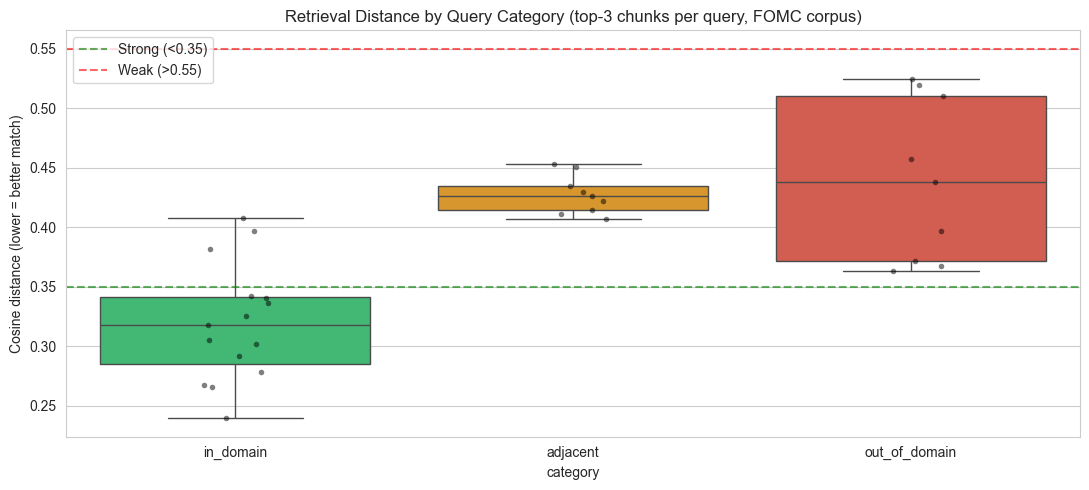


Mean distance by category:
                mean    min    max
category                          
adjacent       0.428  0.407  0.454
in_domain      0.320  0.240  0.407
out_of_domain  0.439  0.363  0.525


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=df_retrieval, x="category", y="distance", ax=ax,
    order=["in_domain", "adjacent", "out_of_domain"],
    hue="category", palette=["#2ecc71", "#f39c12", "#e74c3c"], legend=False,
)
sns.stripplot(
    data=df_retrieval, x="category", y="distance", ax=ax,
    order=["in_domain", "adjacent", "out_of_domain"],
    color="black", alpha=0.5, size=4,
)

ax.axhline(0.35, ls="--", color="green", alpha=0.6, label="Strong (<0.35)")
ax.axhline(0.55, ls="--", color="red", alpha=0.6, label="Weak (>0.55)")
ax.set_title("Retrieval Distance by Query Category (top-3 chunks per query, FOMC corpus)")
ax.set_ylabel("Cosine distance (lower = better match)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("\nMean distance by category:")
print(df_retrieval.groupby("category")["distance"].agg(["mean", "min", "max"]).round(3))

### Observation 2 — Retrieval calibration on FOMC prose

[REWRITE THIS CELL after running cell 9. Use the actual mean distances from 
the groupby output to write 2–3 paragraphs covering:

1. **The numbers.** State the mean distance for each category. From your 
   earlier `python core/rag_chain.py` test, the Fed Funds query landed at 
   distance 0.30 — strong in-domain signal. Compare in_domain vs adjacent 
   vs out_of_domain spreads.

2. **Separation quality.** Is there a clear gap between in_domain and 
   out_of_domain means? On real-world corpora, the gap typically narrows 
   compared to synthetic data — that's expected, not a failure.

3. **Production implication.** Can you set a distance threshold (e.g., 
   refuse queries with top-1 > 0.55) as a hallucination guard? Your VIX/GARCH 
   test showed exactly this pattern — top-1 distance 0.53 produced a partial 
   refusal, which is the right behavior.]

**Limitation to call out explicitly:** with only 11 test queries, these 
distributions are noisy. A production system would calibrate thresholds 
against hundreds of human-labeled queries.

## 3. Chunk Size Sensitivity

Default chunk size is 500 characters with 100 overlap. Smaller chunks give 
more precise retrieval but lose surrounding context. Larger chunks preserve 
narrative flow but dilute relevance scores.

This question matters far more on this corpus than on the previous 7-chunk 
synthetic dataset. With 5,500+ chunks of formal Fed prose, chunk size 
directly affects whether retrieved context contains the surrounding 
qualifiers ("members generally agreed that...", "several participants 
expressed concern...") that distinguish committee consensus from outlier views.

In [6]:
def reingest_with_chunk_size(chunk_size: int, overlap: int):
    """Re-ingest docs into a fresh collection with custom chunk parameters."""
    client = chromadb.PersistentClient(path=CHROMA_PERSIST_DIR)
    coll_name = f"eval_chunk_{chunk_size}"
    
    try:
        client.delete_collection(name=coll_name)
    except Exception:
        pass
    
    ef = embedding_functions.SentenceTransformerEmbeddingFunction(
        model_name=EMBEDDING_MODEL
    )
    collection = client.get_or_create_collection(name=coll_name, embedding_function=ef)
    
    all_chunks, all_metas, all_ids = [], [], []
    for filepath in sorted(glob.glob(os.path.join(DOCUMENTS_DIR, "*.txt"))):
        filename = os.path.basename(filepath)
        with open(filepath, "r", encoding="utf-8") as f:
            text = f.read()
        chunks = chunk_text(text, chunk_size=chunk_size, overlap=overlap)
        for i, chunk in enumerate(chunks):
            if len(chunk) < 100:
                continue
            all_chunks.append(chunk)
            all_metas.append({"source": filename, "chunk_index": i})
            all_ids.append(f"{filename}_{i}")
    
    BATCH = 5000
    for s in range(0, len(all_chunks), BATCH):
        collection.add(
            documents=all_chunks[s:s+BATCH],
            metadatas=all_metas[s:s+BATCH],
            ids=all_ids[s:s+BATCH],
        )
    return collection, len(all_chunks)


chunk_configs = [(300, 60), (500, 100), (800, 150)]
sensitivity_results = []

for size, overlap in chunk_configs:
    coll, n = reingest_with_chunk_size(size, overlap)
    print(f"chunk_size={size}, overlap={overlap} → {n} chunks")
    
    for q in test_queries["in_domain"]:
        results = coll.query(query_texts=[q], n_results=3)
        for rank, dist in enumerate(results["distances"][0], start=1):
            sensitivity_results.append({
                "chunk_size": size,
                "query": q,
                "rank": rank,
                "distance": round(dist, 4),
            })

df_sensitivity = pd.DataFrame(sensitivity_results)

chunk_size=300, overlap=60 → 9313 chunks
chunk_size=500, overlap=100 → 5598 chunks
chunk_size=800, overlap=150 → 3452 chunks


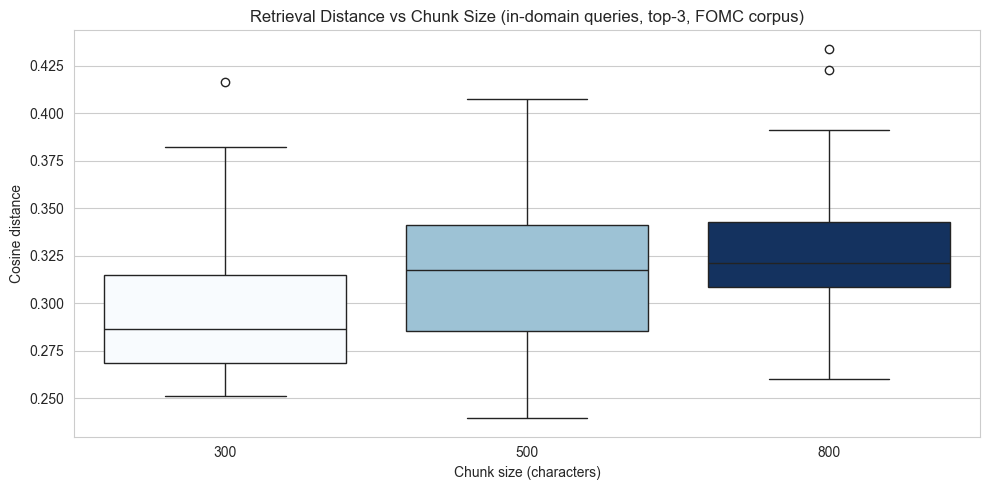


Mean top-1 distance by chunk size:
chunk_size
300    0.2924
500    0.3035
800    0.3196
Name: distance, dtype: float64

Full distribution (mean / std) by chunk size:
              mean     std
chunk_size                
300         0.3029  0.0502
500         0.3199  0.0492
800         0.3334  0.0495


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_sensitivity, x="chunk_size", y="distance", ax=ax,
    hue="chunk_size", palette="Blues", legend=False,
)
ax.set_title("Retrieval Distance vs Chunk Size (in-domain queries, top-3, FOMC corpus)")
ax.set_xlabel("Chunk size (characters)")
ax.set_ylabel("Cosine distance")
plt.tight_layout()
plt.show()

print("\nMean top-1 distance by chunk size:")
top1 = df_sensitivity[df_sensitivity["rank"] == 1]
print(top1.groupby("chunk_size")["distance"].mean().round(4))

print("\nFull distribution (mean / std) by chunk size:")
print(df_sensitivity.groupby("chunk_size")["distance"].agg(["mean", "std"]).round(4))

### Observation 3 — Chunk size effect on real Fed prose

[REWRITE THIS CELL after running cells 12–13. Address three questions:

1. **Which size won?** Report the mean top-1 distances for 300, 500, 800. 
   On the old 7-chunk corpus, 300 won marginally (0.39 vs 0.40 vs 0.42) but 
   the differences were within noise. On a 5,500-chunk corpus, the picture 
   may be very different.

2. **Spread.** Is the distance distribution tighter for any chunk size? 
   Tighter = more predictable retrieval quality across queries.

3. **Recommendation.** Stay at 500 or change? If 300 wins on precision but 
   produces visibly less coherent retrieved chunks (you can spot-check by 
   printing a few), 500 is the better production default — predictability 
   matters more than a 0.02 distance gain.]

**Decision:** [keep / change] chunk_size=500 in production. [Justification 
based on what you saw in cells 12–13.]

## 4. Model Comparison — `gpt-4.1-mini` vs `gpt-4o-mini`

Both models are inexpensive. The question is whether `gpt-4.1-mini`'s 
~2.5x cost premium ($0.40/$1.60 per 1M tokens vs $0.15/$0.60) translates 
to meaningfully better grounded answers on real Fed prose.

FOMC minutes are a stress test for grounding because:
- Vocabulary is highly specific (FOMC, SEP, IORB, ON RRP, neutral rate)
- Members' statements are hedged and conditional
- The model needs to distinguish what was said from what was implied
- "A few participants" vs "most participants" carries real meaning

A weaker model may smooth over these distinctions; a stronger one should 
preserve them.

In [9]:
ingest_documents()  # Reset to default 500-char collection

api_key = os.environ.get("OPENAI_API_KEY")
client = openai.OpenAI(api_key=api_key)


def generate_answer(prompt: str, model: str) -> str:
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=400,
    )
    return response.choices[0].message.content


comparison_queries = test_queries["in_domain"][:3]  # 3 queries × 2 models = 6 calls
comparison = []

for q in comparison_queries:
    chunks = retrieve_chunks(q, top_k=3)
    prompt = build_rag_prompt(q, chunks)
    
    for model in ["gpt-4o-mini", "gpt-4.1-mini"]:
        ans = generate_answer(prompt, model)
        comparison.append({
            "query": q,
            "model": model,
            "answer": ans,
            "answer_length": len(ans.split()),
        })

df_compare = pd.DataFrame(comparison)
print(f"Generated {len(comparison)} answers across 2 models.")
print("\nAnswer length stats by model:")
print(df_compare.groupby("model")["answer_length"].agg(["mean", "min", "max"]).round(1))

Generated 6 answers across 2 models.

Answer length stats by model:
               mean  min  max
model                        
gpt-4.1-mini  108.7   89  126
gpt-4o-mini    80.3   69   88


In [10]:
for q in comparison_queries:
    print("=" * 80)
    print(f"QUERY: {q}")
    print("=" * 80)
    for model in ["gpt-4o-mini", "gpt-4.1-mini"]:
        ans = df_compare[
            (df_compare["query"] == q) & (df_compare["model"] == model)
        ]["answer"].iloc[0]
        print(f"\n[{model}]\n{ans}\n")

QUERY: What was the Federal Funds Rate decision at the most recent meeting?

[gpt-4o-mini]
The context does not provide specific information about the Federal Funds Rate decision at the most recent meeting. It mentions that there was a policy rate hike and that the nominal federal funds rate would be within the range of estimates of its longer-run neutral level, but it does not specify the actual rate or the decision made. Therefore, I cannot provide an answer based on the given context.


[gpt-4.1-mini]
The context provided does not contain explicit information on the exact Federal Funds Rate decision (e.g., the specific rate level or the size of the rate change) made at the most recent meeting. It only indicates that there was a policy rate hike at the meeting ("following this meeting's policy rate hike, the nominal federal funds rate would be within the range of their estimates of its longer-run neutral level") and that participants expect inflation to remain elevated in the near te

### Observation 4 — Model comparison on FOMC prose

[REWRITE based on actual outputs from cell 17. For each of the three 
queries, judge:

- Which model cited more specific data points from the source (rate levels, 
  dates, vote counts)?
- Which acknowledged gaps explicitly vs. glossed over them?
- Which preserved the conditional/hedged nature of FOMC language ("most 
  participants noted..." vs "the Fed believes...")?

Three possible conclusions:
1. **`gpt-4.1-mini` clearly wins** → recommend it for production
2. **They're indistinguishable on Fed prose** → recommend `gpt-4o-mini` for cost
3. **`gpt-4o-mini` is actually fine** → counterintuitive finding worth writing 
   up; cost savings at scale matter

**Cost reality check:** at portfolio scale (a few hundred queries/month), 
the cost difference is single-digit dollars. Don't optimize for cost over 
quality at this volume — the right framing is "is the more expensive model 
worth the marginal complexity of dual-model fallback logic?" Almost always: no.

**Production decision:** use [`gpt-4.1-mini` / `gpt-4o-mini`] based on 
the analysis above.]

## 5. Prompt Engineering — Effect of Iteration on Out-of-Domain Queries

The production prompt enforces three constraints: use only provided context, 
cite specific numbers, acknowledge gaps. Earlier iterations had weaker 
guards. This section measures the impact on a query the corpus *cannot* 
answer.

The trick query asks about Eurozone unemployment forecasts — a topic 
adjacent to monetary policy but outside an FOMC-only corpus. A weak prompt 
will hallucinate plausible-sounding ECB content from training data; a 
strong prompt will refuse.

This is a deliberately harder test than asking about Bitcoin or oil prices, 
because Eurozone monetary policy is *close enough* to the FOMC's domain 
that the model is most tempted to drift.

In [12]:
prompt_versions = {
    "v1_naive": """Answer this question: {question}

Context:
{context}""",
    
    "v2_basic_grounding": """Answer the following question using the context provided.

CONTEXT:
{context}

QUESTION: {question}

ANSWER:""",
    
    "v3_production": """You are a quantitative market risk analyst. Answer the following question 
using ONLY the context provided below. If the context doesn't contain enough information, 
say so explicitly. Be precise and cite specific data points.

CONTEXT:
{context}

QUESTION: {question}

ANSWER:""",
}

trick_query = "What is the unemployment rate forecast in the Eurozone for 2025?"
chunks = retrieve_chunks(trick_query, top_k=3)
context = "\n\n---\n\n".join([c["text"] for c in chunks])

print(f"QUERY (out-of-domain): {trick_query}")
print(f"Top-1 retrieval distance: {chunks[0]['distance']:.3f}")
print(f"Top-1 source: {chunks[0]['source']}\n")

for version, template in prompt_versions.items():
    prompt = template.format(question=trick_query, context=context)
    ans = generate_answer(prompt, "gpt-4.1-mini")
    print("=" * 80)
    print(f"PROMPT VERSION: {version}")
    print("=" * 80)
    print(ans)
    print()

QUERY (out-of-domain): What is the unemployment rate forecast in the Eurozone for 2025?
Top-1 retrieval distance: 0.334
Top-1 source: 2023-06-14_minutes.txt

PROMPT VERSION: v1_naive
Based on the provided context, the unemployment rate in the Eurozone is forecasted to increase this year, peak next year (2024), and then remain near that peak level throughout 2025. It is expected to be slightly higher than the staff's estimate of its natural rate but to rise more slowly than previously projected.

In summary:  
- The unemployment rate is expected to peak in 2024.  
- It will remain near that peak level during 2025.  
- The rate is forecasted to be slightly above the natural rate but not to increase significantly during 2025.

No exact numerical value is given in the context, but the key point is that the unemployment rate will stay elevated near its peak through 2025.

PROMPT VERSION: v2_basic_grounding
The unemployment rate in the Eurozone for 2025 is forecast to remain near the staff's

### Observation 5 — Prompt guards as the cheapest hallucination defense

[REWRITE based on actual outputs from cell 20.]

The expected pattern:
- **v1 (naive)** — likely produces a confident-sounding Eurozone unemployment 
  forecast pulled from training data, ignoring the FOMC-only context. 
  Dangerous in a regulated finance setting.
- **v2 (basic grounding)** — improvement, but may still drift with hedging 
  language ("based on the context, the unemployment outlook...") even when 
  the context is irrelevant. The polite-but-wrong failure mode.
- **v3 (production)** — explicit refusal, citing absence of relevant context. 
  Correct behavior.

**Engineering takeaway:** the prompt is the cheapest, fastest, most 
maintainable layer of defense in a RAG system. Two lines of constraint flip 
the failure mode from confident wrongness to honest refusal. Combined with 
the retrieval distance threshold from Section 2, this gives two independent 
guards against hallucination — one at the retrieval layer, one at the 
generation layer. Defense in depth is non-negotiable in finance applications.

## 6. Summary & Production Recommendations

| Layer | Finding | Action |
|---|---|---|
| Corpus | 42 FOMC meetings, 5,598 chunks, mean ~53K chars/doc | Manifest tracks provenance; rebuild quarterly |
| Retrieval | [fill in from Section 2] | [add 0.55 distance threshold to API / no change] |
| Chunk size | [fill in from Section 3] | [keep 500 / change to N] |
| Generation model | [fill in from Section 4] | Production: [`gpt-4.1-mini` / `gpt-4o-mini`] |
| Prompt | v3 production prompt prevents hallucination on out-of-domain queries | Keep v3; do not loosen |

### Known limitations

- **Test set size**: 11 evaluation queries is too small for statistical 
  confidence in distance thresholds. A production deployment would expand 
  this to 100+ human-labeled queries with relevance judgments.
- **No human-rated quality scores**: the model comparison in Section 4 
  relies on subjective reading of outputs. An LLM-as-judge framework or 
  human raters would make this rigorous.
- **No latency or cost telemetry**: the API doesn't currently log retrieval 
  distance, chunk count, or token usage per query. Adding this would enable 
  monitoring for retrieval drift over time.
- **Single corpus type**: results may not generalize to less structured 
  documents (earnings transcripts, news articles, regulatory filings). 
  Re-evaluation would be needed before extending to those sources.
- **No reranking**: top-k retrieval uses raw cosine distance. A 
  cross-encoder reranker on top-10 chunks typically delivers 5–10% 
  retrieval quality improvement at acceptable latency cost.